<a href="https://colab.research.google.com/github/bhaleraokanhiya-ops/OIBSIP/blob/main/Task2_Unemployment_Analysis/Kanhaiya_Task2_Unemployment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/AvinashHanumantWagh/OIBSIPTask2/main/Unemployment_Rate_upto_11_2020.csv"
df = pd.read_csv(url)
df.columns = df.columns.str.strip()
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,Longitude,Latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [3]:
print(df.info())
print(df.isnull().sum())
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Region                                   267 non-null    object 
 1   Date                                     267 non-null    object 
 2   Frequency                                267 non-null    object 
 3   Estimated Unemployment Rate (%)          267 non-null    float64
 4   Estimated Employed                       267 non-null    int64  
 5   Estimated Labour Participation Rate (%)  267 non-null    float64
 6   Region.1                                 267 non-null    object 
 7   Longitude                                267 non-null    float64
 8   Latitude                                 267 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 18.9+ KB
None
Region                                     0
Date         

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Longitude,Latitude
count,267,267.000000,2.670000e+02,267.000000,267.000000,267.000000
mean,2020-06-16 09:15:30.337078528,12.236929,1.396211e+07,41.681573,22.826048,80.532425
min,2020-01-31 00:00:00,0.500000,1.175420e+05,16.770000,10.850500,71.192400
25%,2020-03-31 00:00:00,4.845000,2.838930e+06,37.265000,18.112400,76.085600
50%,2020-06-30 00:00:00,9.650000,9.732417e+06,40.390000,23.610200,79.019300
75%,2020-08-31 00:00:00,16.755000,2.187869e+07,44.055000,27.278400,85.279900
max,2020-10-31 00:00:00,75.850000,5.943376e+07,69.690000,33.778200,92.937600
std,NaN,10.803283,1.336632e+07,7.845419,6.270731,5.831738


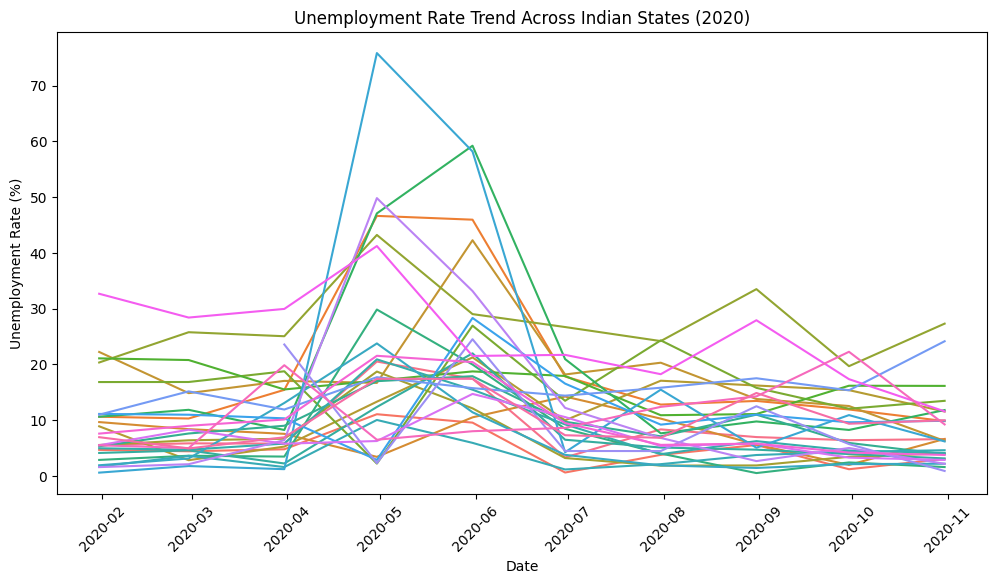

In [4]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df, x='Date', y='Estimated Unemployment Rate (%)', hue='Region', legend=False)
plt.title('Unemployment Rate Trend Across Indian States (2020)')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.savefig('unemployment_trend.png')
plt.show()

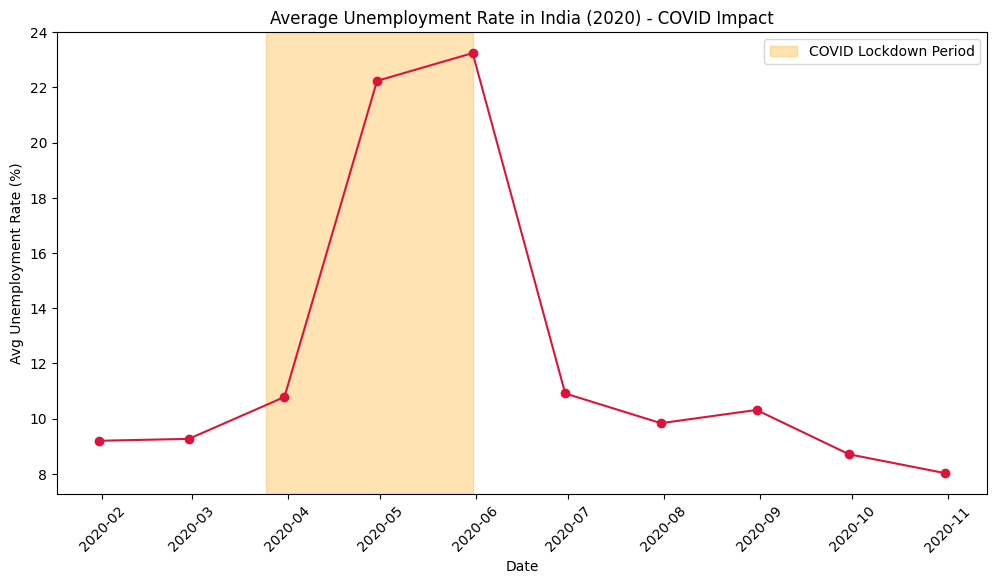

In [5]:
avg_by_date = df.groupby('Date')['Estimated Unemployment Rate (%)'].mean().reset_index()

plt.figure(figsize=(12,6))
plt.plot(avg_by_date['Date'], avg_by_date['Estimated Unemployment Rate (%)'], marker='o', color='crimson')
plt.axvspan(pd.Timestamp('2020-03-25'), pd.Timestamp('2020-05-31'), color='orange', alpha=0.3, label='COVID Lockdown Period')
plt.title('Average Unemployment Rate in India (2020) - COVID Impact')
plt.xlabel('Date')
plt.ylabel('Avg Unemployment Rate (%)')
plt.legend()
plt.xticks(rotation=45)
plt.savefig('covid_spike.png')
plt.show()

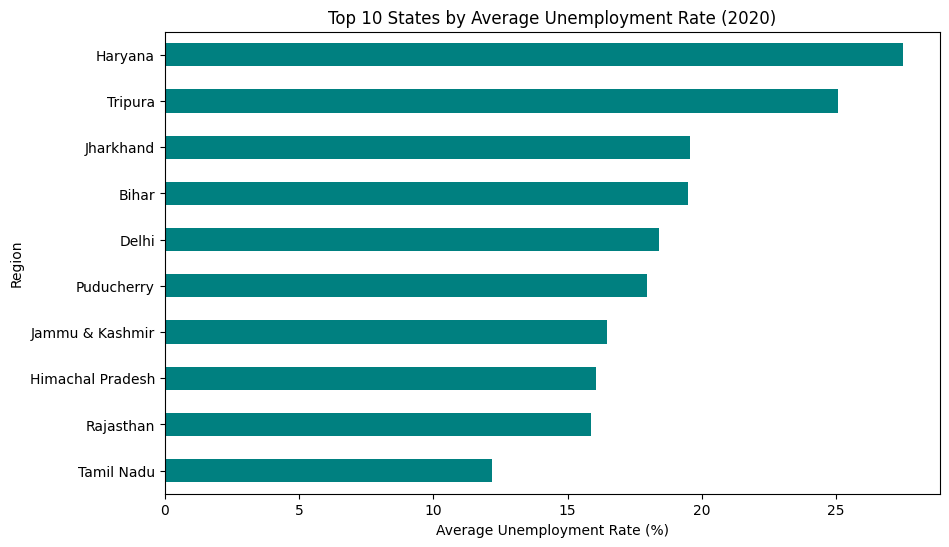

In [6]:
state_avg = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
state_avg.plot(kind='barh', color='teal')
plt.title('Top 10 States by Average Unemployment Rate (2020)')
plt.xlabel('Average Unemployment Rate (%)')
plt.gca().invert_yaxis()
plt.savefig('top10_states.png')
plt.show()

In [7]:
if 'Area' in df.columns:
    plt.figure(figsize=(8,5))
    sns.boxplot(data=df, x='Area', y='Estimated Unemployment Rate (%)')
    plt.title('Unemployment Rate: Rural vs Urban')
    plt.savefig('rural_urban.png')
    plt.show()
else:
    print("No 'Area' column found in this dataset version.")

No 'Area' column found in this dataset version.
